# Introduction

## Purpose

This notebook explores the SE3 electricity-price dataset. It checks data quality, identifies patterns in prices, and examines which weather and time features may help forecast electricity prices.

# Imports

In [ ]:
import sys

# Allow the notebook to import modules from the project root.
sys.path.append("..")

from backend.app.ml.preprocessing import prepare_data

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load the raw dataset.
df = pd.read_csv("../dataset/se3_weather_and_prices.csv")

df.head()

,timestamp,temperature_c,wind_speed_kmh,rain_mm,spot_price_eur_mwh,timestamp_local
0,2025-01-01 00:00:00+00:00,-0.6,18.4,0.0,2.47,2025-01-01 01:00:00+01:00
1,2025-01-01 01:00:00+00:00,0.2,12.7,0.0,2.44,2025-01-01 02:00:00+01:00
2,2025-01-01 02:00:00+00:00,0.6,5.2,0.1,1.98,2025-01-01 03:00:00+01:00
3,2025-01-01 03:00:00+00:00,1.2,6.5,0.1,1.79,2025-01-01 04:00:00+01:00
4,2025-01-01 04:00:00+00:00,1.5,7.6,0.1,2.71,2025-01-01 05:00:00+01:00


In [ ]:
# Apply the project's preprocessing steps and check for missing values.
df_prepared = prepare_data(df)

df_prepared.isna().sum()

timestamp               0
temperature_c           0
wind_speed_kmh          0
rain_mm                 0
spot_price_eur_mwh      0
timestamp_local         0
hour                    0
day_of_week             0
month                   0
is_weekend              0
price_lag_24           24
price_lag_48           48
price_lag_168         168
dtype: int64

In [4]:
df.shape

(4345, 6)

In [5]:
df.columns.tolist()

['timestamp',
 'temperature_c',
 'wind_speed_kmh',
 'rain_mm',
 'spot_price_eur_mwh',
 'timestamp_local']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4345 entries, 0 to 4344
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           4345 non-null   str    
 1   temperature_c       4345 non-null   float64
 2   wind_speed_kmh      4345 non-null   float64
 3   rain_mm             4345 non-null   float64
 4   spot_price_eur_mwh  4345 non-null   float64
 5   timestamp_local     4345 non-null   str    
dtypes: float64(4), str(2)
memory usage: 203.8 KB


In [ ]:
# Convert timestamps to UTC and Swedish local time for time-based analysis.
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

df["timestamp_local"] = pd.to_datetime(
    df["timestamp_local"],
    utc=True
).dt.tz_convert("Europe/Stockholm")

In [8]:
print("Start:", df["timestamp_local"].min())
print("End:", df["timestamp_local"].max())
print("Number of rows:", len(df))

Start: 2025-01-01 01:00:00+01:00
End: 2025-07-01 02:00:00+02:00
Number of rows: 4345


In [9]:
print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

Duplicate timestamps: 0


In [10]:
print(
    "Chronologically sorted:",
    df["timestamp"].is_monotonic_increasing
)

Chronologically sorted: True


In [11]:
time_diff = df["timestamp"].diff()

time_diff.value_counts().sort_index()

timestamp
0 days 01:00:00    4344
Name: count, dtype: int64

In [ ]:
# Add yesterday's price at the same hour as a forecasting feature.
df["price_lag_24"] = df["spot_price_eur_mwh"].shift(24)

# EDA

In [13]:
df["spot_price_eur_mwh"].describe()

count    4345.00000
mean       43.82270
std        43.16613
min       -25.05000
25%        15.86000
50%        32.44000
75%        57.29000
max       393.38000
Name: spot_price_eur_mwh, dtype: float64

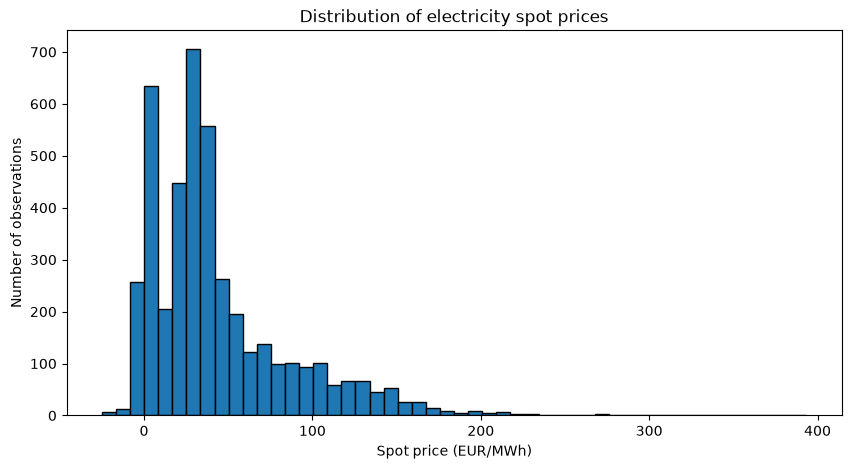

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["spot_price_eur_mwh"],
    bins=50,
    edgecolor="black"
)

plt.xlabel("Spot price (EUR/MWh)")
plt.ylabel("Number of observations")
plt.title("Distribution of electricity spot prices")

plt.show()

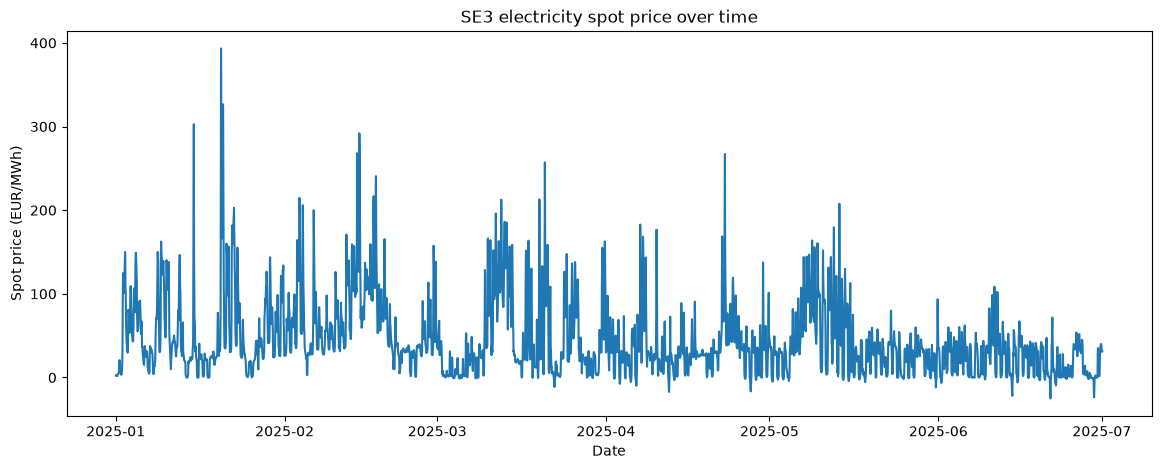

In [16]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["timestamp_local"],
    df["spot_price_eur_mwh"]
)

plt.xlabel("Date")
plt.ylabel("Spot price (EUR/MWh)")
plt.title("SE3 electricity spot price over time")

plt.show()

In [17]:
print(
    "Negative prices:",
    (df["spot_price_eur_mwh"] < 0).sum()
)

print(
    "Zero prices:",
    (df["spot_price_eur_mwh"] == 0).sum()
)

print(
    "Prices above 100 EUR/MWh:",
    (df["spot_price_eur_mwh"] > 100).sum()
)

print(
    "Prices above 200 EUR/MWh:",
    (df["spot_price_eur_mwh"] > 200).sum()
)

Negative prices: 250
Zero prices: 15
Prices above 100 EUR/MWh: 511
Prices above 200 EUR/MWh: 31


In [18]:
df["hour"] = df["timestamp_local"].dt.hour

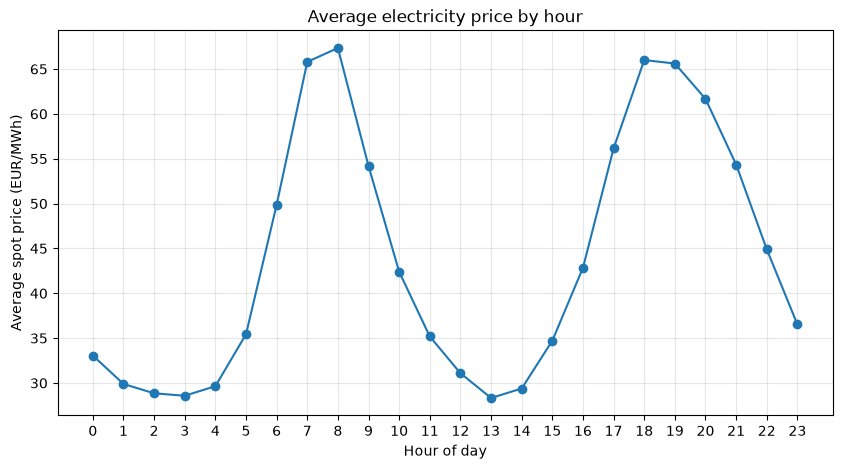

In [19]:
hourly_price = (
    df.groupby("hour")["spot_price_eur_mwh"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_price.index,
    hourly_price.values,
    marker="o"
)

plt.xticks(range(24))
plt.xlabel("Hour of day")
plt.ylabel("Average spot price (EUR/MWh)")
plt.title("Average electricity price by hour")

plt.grid(alpha=0.3)
plt.show()

In [20]:
df["spot_price_eur_mwh"].describe()

count    4345.00000
mean       43.82270
std        43.16613
min       -25.05000
25%        15.86000
50%        32.44000
75%        57.29000
max       393.38000
Name: spot_price_eur_mwh, dtype: float64

### Initial observations

Prices range from -25.05 to 393.38 EUR/MWh. The mean price is higher than the median, which suggests that occasional high prices pull the distribution to the right.

Negative prices and price spikes are kept because they are valid market outcomes and matter for forecasting.

In [21]:
weather_features = [
    "temperature_c",
    "wind_speed_kmh",
    "rain_mm"
]

df[weather_features].describe()

,temperature_c,wind_speed_kmh,rain_mm
count,4345.000000,4345.000000,4345.000000
mean,5.887043,12.334108,0.033349
std,7.050592,5.881332,0.197648
min,-14.300000,0.000000,0.000000
25%,1.200000,8.000000,0.000000
50%,5.300000,11.600000,0.000000
75%,11.100000,16.100000,0.000000
max,27.300000,32.800000,4.700000


In [ ]:
# Measure linear relationships between weather variables and electricity price.
correlations = df[
    [
        "temperature_c",
        "wind_speed_kmh",
        "rain_mm",
        "spot_price_eur_mwh"
    ]
].corr()

correlations

,temperature_c,wind_speed_kmh,rain_mm,spot_price_eur_mwh
temperature_c,1.000000,0.145643,0.079837,-0.443439
wind_speed_kmh,0.145643,1.000000,0.027833,-0.283828
rain_mm,0.079837,0.027833,1.000000,-0.047681
spot_price_eur_mwh,-0.443439,-0.283828,-0.047681,1.000000


In [23]:
correlations["spot_price_eur_mwh"].sort_values(
    ascending=False
)

spot_price_eur_mwh    1.000000
rain_mm              -0.047681
wind_speed_kmh       -0.283828
temperature_c        -0.443439
Name: spot_price_eur_mwh, dtype: float64

### Correlation observations

Temperature has the strongest linear relationship with price: higher temperatures are generally linked to lower prices. Wind speed also has a weaker negative relationship, while rain has almost no linear relationship.

Correlation does not prove cause and effect. Weather, demand, generation, and market conditions can all influence price. Features with weak linear correlations may still help a nonlinear model such as Random Forest.

In [ ]:
# Create time-based features for price-pattern analysis and forecasting.
df["hour"] = df["timestamp_local"].dt.hour
df["day_of_week"] = df["timestamp_local"].dt.dayofweek
df["month"] = df["timestamp_local"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

In [25]:
hourly_prices = (
    df.groupby("hour")["spot_price_eur_mwh"]
    .mean()
)

hourly_prices

hour
0     33.059282
1     29.892253
2     28.852873
3     28.576077
4     29.648674
5     35.425138
6     49.866077
7     65.798674
8     67.345193
9     54.184144
10    42.400331
11    35.184254
12    31.090552
13    28.328343
14    29.386133
15    34.715691
16    42.840055
17    56.146961
18    66.001215
19    65.612431
20    61.677072
21    54.356851
22    44.906354
23    36.527127
Name: spot_price_eur_mwh, dtype: float64

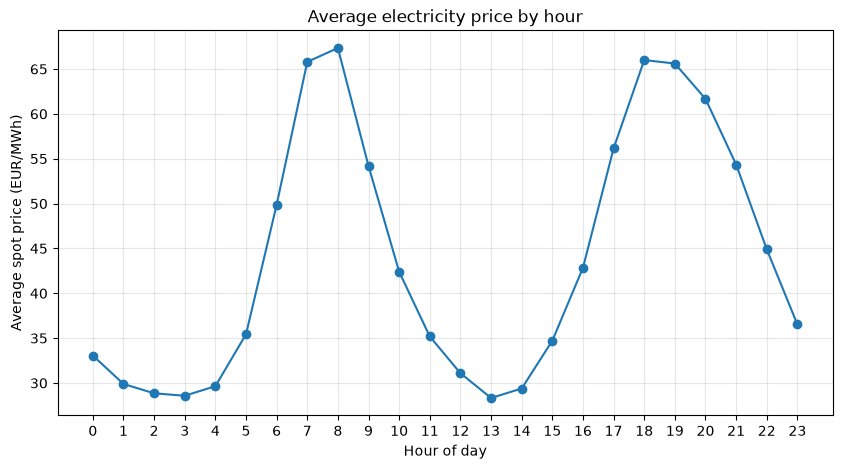

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_prices.index,
    hourly_prices.values,
    marker="o"
)

plt.xticks(range(24))
plt.xlabel("Hour of day")
plt.ylabel("Average spot price (EUR/MWh)")
plt.title("Average electricity price by hour")
plt.grid(alpha=0.3)

plt.show()

In [28]:
weekday_prices = (
    df.groupby("day_of_week")["spot_price_eur_mwh"]
    .mean()
)

weekday_prices

day_of_week
0    52.124920
1    46.285075
2    50.834061
3    52.872051
4    45.939327
5    28.651458
6    30.124157
Name: spot_price_eur_mwh, dtype: float64

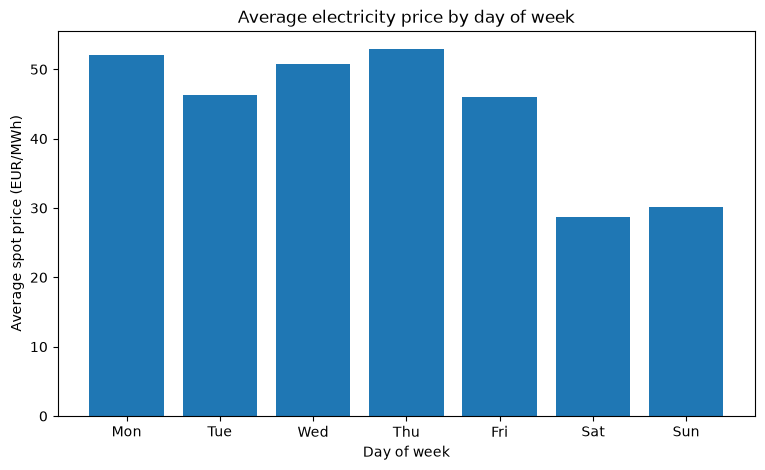

In [29]:
weekday_names = [
    "Mon", "Tue", "Wed", "Thu",
    "Fri", "Sat", "Sun"
]

plt.figure(figsize=(9, 5))

plt.bar(
    weekday_prices.index,
    weekday_prices.values
)

plt.xticks(
    weekday_prices.index,
    weekday_names
)

plt.xlabel("Day of week")
plt.ylabel("Average spot price (EUR/MWh)")
plt.title("Average electricity price by day of week")

plt.show()

### Time-based patterns

Prices change throughout the day. They are usually lowest at night and in the early afternoon, with clear peaks in the morning and evening.

Weekend prices are lower than weekday prices. This makes hour, day of week, and weekend status useful features for the forecasting model.

In [30]:
monthly_prices = (
    df.groupby("month")["spot_price_eur_mwh"]
    .agg(["mean", "median", "std", "count"])
)

monthly_prices

,mean,median,std,count
month,,,,
1,55.321467,36.380,51.338048,743
2,68.276622,54.395,46.212771,672
3,46.319004,26.220,48.833842,743
4,34.236306,29.370,30.659309,720
5,39.409315,33.030,36.187187,744
6,20.754722,17.805,21.042264,720
7,31.600000,31.390,1.060707,3
